<a href="https://colab.research.google.com/github/HamzaEric/Pet_Breed_Classification/blob/main/Notebooks/Evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
device = 'cpu'
print(f"Using device: {device}")

IMG_SIZE = 128
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # [-1, 1] range
])

data_path = "./data"
test_dataset = datasets.OxfordIIITPet(
    root=data_path,
    split="test",
    target_types="category",
    transform=transform,
    download=True
)

# DataLoader
BATCH_SIZE = 32
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test dataset size: {len(test_dataset)} images")
print(f"Number of classes: {len(test_dataset.classes)}")
print(f"Example classes: {test_dataset.classes[:5]}")

class PetCNN(nn.Module):
    def __init__(self):
        super(PetCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3→16
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16→32
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 37)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 3×128×128 → 16×64×64
        x = self.pool(F.relu(self.conv2(x)))   # 16×64×64 → 32×32×32
        x = x.view(-1, 32 * 32 * 32)           # flatten
        x = F.relu(self.fc1(x))                # → 128
        x = self.fc2(x)                        # → 37 logits
        return x

# Instantiate and load weights
model = PetCNN().to(device)
model.load_state_dict(torch.load("petcnn_best.pth", weights_only=False))
model.eval()

print("Model and weights loaded successfully.")


Using device: cpu
Test dataset size: 3669 images
Number of classes: 37
Example classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
Model and weights loaded successfully.


In [6]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -----------------------------
# 2. Overall accuracy
# -----------------------------
overall_acc = accuracy_score(all_labels, all_preds)
print(f"Overall Test Accuracy: {overall_acc:.4f}")

# -----------------------------
# 3. Per-class accuracy
# -----------------------------
class_correct = np.zeros(len(test_dataset.classes))
class_total = np.zeros(len(test_dataset.classes))

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

per_class_acc = class_correct / class_total

# Top 5 best and worst classes
sorted_indices = np.argsort(per_class_acc)
worst_indices = sorted_indices[:5]
best_indices = sorted_indices[-5:][::-1]

print("\nTop 5 Worst-Performing Classes:")
for idx in worst_indices:
    print(f"{test_dataset.classes[idx]}: {per_class_acc[idx]*100:.2f}%")

print("\nTop 5 Best-Performing Classes:")
for idx in best_indices:
    print(f"{test_dataset.classes[idx]}: {per_class_acc[idx]*100:.2f}%")

# -----------------------------
# 4. Classification Report
# -----------------------------
report = classification_report(all_labels, all_preds, target_names=test_dataset.classes, zero_division=0)
print("\nClassification Report:\n")
print(report)

Overall Test Accuracy: 0.1344

Top 5 Worst-Performing Classes:
American Pit Bull Terrier: 0.00%
Chihuahua: 0.00%
English Setter: 0.00%
Miniature Pinscher: 0.00%
Wheaten Terrier: 0.00%

Top 5 Best-Performing Classes:
Newfoundland: 41.00%
Bengal: 39.00%
Basset Hound: 37.00%
Leonberger: 37.00%
Samoyed: 36.00%

Classification Report:

                            precision    recall  f1-score   support

                Abyssinian       0.16      0.06      0.09        98
          American Bulldog       0.11      0.14      0.12       100
 American Pit Bull Terrier       0.00      0.00      0.00       100
              Basset Hound       0.08      0.37      0.13       100
                    Beagle       0.12      0.10      0.11       100
                    Bengal       0.17      0.39      0.24       100
                    Birman       0.44      0.12      0.19       100
                    Bombay       0.43      0.20      0.28        88
                     Boxer       0.07      0.04      0

**Reflection on Per-Class Results**

**Overall Accuracy**  
- The baseline CNN achieves **~13% accuracy**, only slightly better than random guessing (≈2.7% for 37 classes).  
- This indicates the model is picking up **basic low-level features** (edges, colors) but struggles to distinguish between visually similar breeds.


**Best-Performing Breeds**  
- Breeds like **Newfoundland** and **Bombay** perform comparatively well.  
- These breeds have **distinctive visual traits** that may stand out even to a shallow CNN:
  - Newfoundland: uniformly dark, large-bodied dogs.
  - Samoyed: bright white fluffy coats with distinct textures.
  - Bombay: solid black cats with round faces and short fur.
- The relatively high performance suggests that **simple texture and color cues** were enough for these classes.


**Worst-Performing Breeds**  
- Some classes, including **American Pit Bull Terrier or Chihuahua**, scored **near 0% accuracy**.  
- Likely reasons:
  - **High visual overlap** with other breeds (e.g., several small dog breeds look similar in color and size).
  - **Pose and background variations** masking distinctive features.
  - The model may have failed to learn **fine-grained cues** (e.g., subtle fur patterns) due to limited depth or training epochs.

**Macro vs Weighted Metrics**  
- **Macro F1-score (~0.12):** Shows uniformly poor performance when treating all classes equally — the model fails to generalize across most breeds.  
- **Weighted F1-score (~0.12):** Similar to macro, indicating no strong bias toward high-frequency classes (but overall low predictive power).

**Key Takeaways**  
- The model is **far from production-ready**: it recognizes a handful of distinctive breeds but misclassifies most others.  
- To improve:
  - **Data augmentation** (rotations, flips, color jitter) to help learn pose- and lighting-invariant features.
  - **Deeper architectures** (e.g., VGG-like or ResNet) to capture complex textures and shapes.
  - **Class weighting or sampling strategies** to mitigate imbalance between breeds.
  - Potential use of **transfer learning** to leverage pretrained features on similar large-scale image datasets.

Next, we will visualize the **confusion matrix** to pinpoint **which breeds are most commonly confused with each other**, offering further insight into model weaknesses.

---

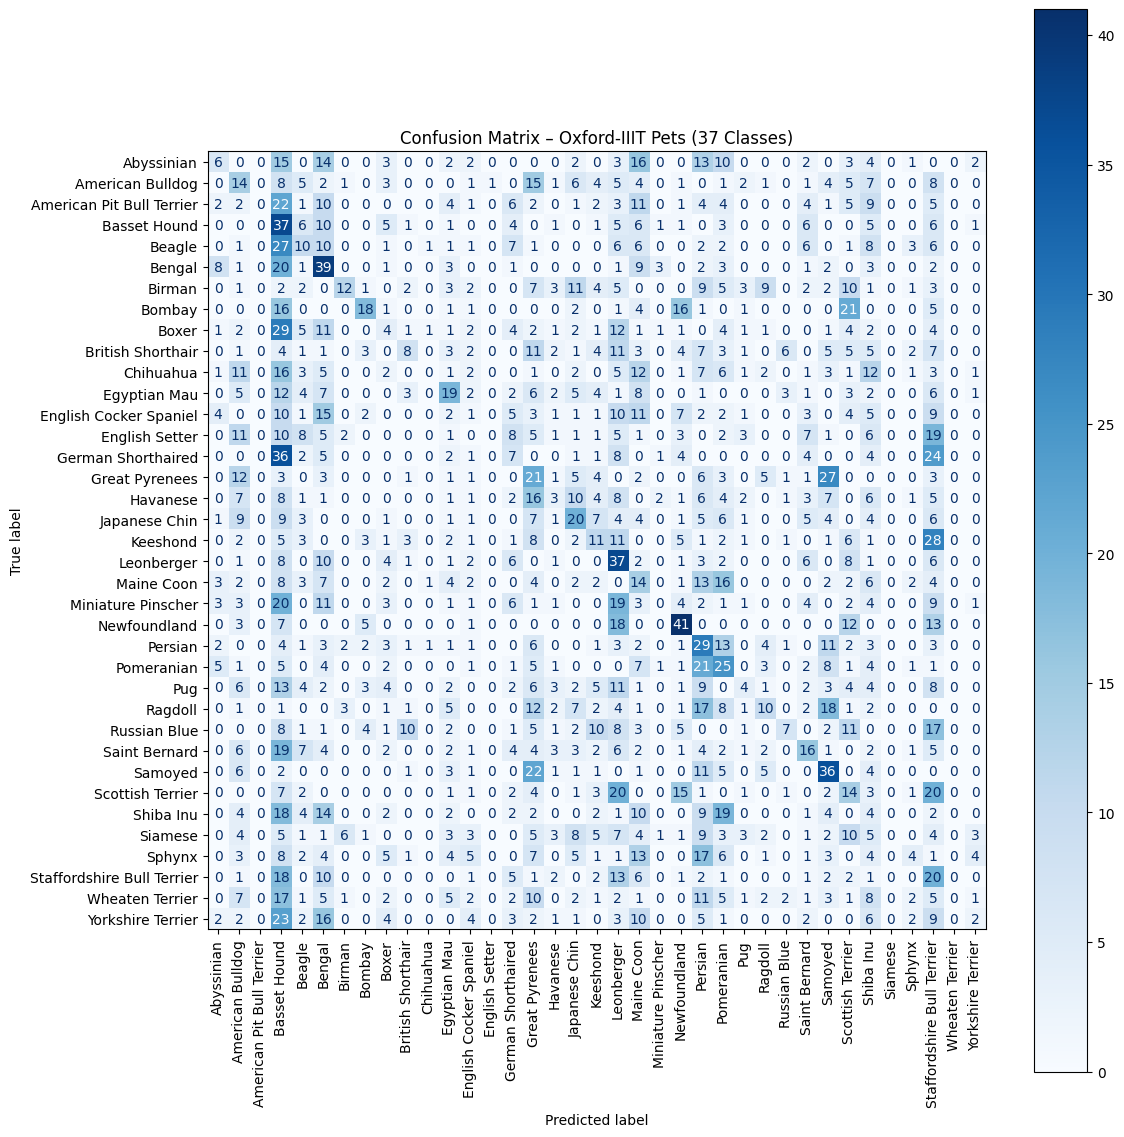

In [8]:
class_names = test_dataset.classes

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

disp.plot(ax=ax,
          xticks_rotation='vertical',
          cmap='Blues',
          colorbar=True)

plt.title("Confusion Matrix – Oxford-IIIT Pets (37 Classes)")
plt.tight_layout()
plt.show()

In [11]:
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix as DataFrame:\n")
print(cm_df)

# save as CSV
cm_df.to_csv("confusion_matrix.csv", index=True)


Confusion Matrix as DataFrame:

                            Abyssinian  American Bulldog  \
Abyssinian                           6                 0   
American Bulldog                     0                14   
American Pit Bull Terrier            2                 2   
Basset Hound                         0                 0   
Beagle                               0                 1   
Bengal                               8                 1   
Birman                               0                 1   
Bombay                               0                 0   
Boxer                                1                 2   
British Shorthair                    0                 1   
Chihuahua                            1                11   
Egyptian Mau                         0                 5   
English Cocker Spaniel               4                 0   
English Setter                       0                11   
German Shorthaired                   0                 0   
Great P

# Qualitative Error Analysis

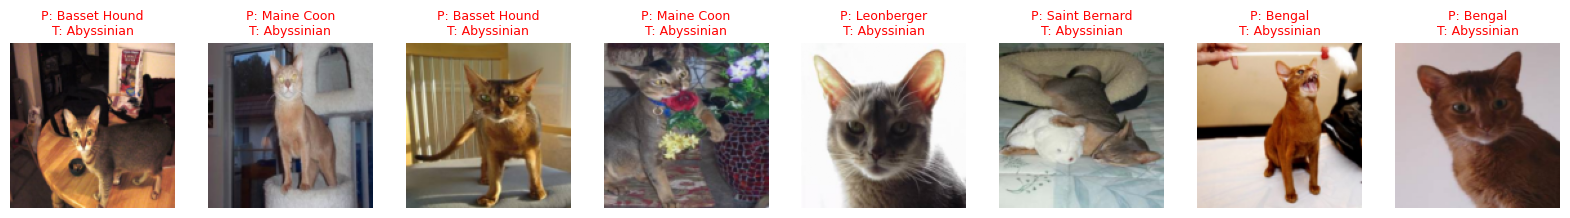

In [12]:

def show_misclassified_samples(model, loader, classes, n=8):
    """
    Displays n misclassified test images with predicted vs true labels.
    """
    model.eval()
    misclassified = []

    # Gather misclassified samples
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(1).cpu()

            for img, pred, true in zip(images, preds, labels):
                if pred != true:
                    misclassified.append((img, pred.item(), true.item()))
                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break

    # Display misclassified samples
    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    for i, (img, pred, true) in enumerate(misclassified):
        img = img * 0.5 + 0.5  # unnormalize back to [0,1]
        axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
        axes[i].set_title(f"P: {classes[pred]}\nT: {classes[true]}", fontsize=9, color="red")
        axes[i].axis("off")
    plt.show()

# Run visualization
show_misclassified_samples(model, test_loader, test_dataset.classes, n=8)